<a href="https://colab.research.google.com/github/Laft99/Machine-Learning/blob/main/imageRecongition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
import urllib.request
import zipfile
from tensorflow.keras.layers import Conv2D
from keras.models import Sequential
from keras.layers import  MaxPooling2D, Activation, Dropout, Flatten, Dense
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/100x100only.zip'
# Create directory to extract to
extract_path = '/content/fruitsReady'
os.makedirs(extract_path, exist_ok=True)

# Extract the dataset
print("Extracting files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Extracting files...
Dataset extracted successfully!


In [ ]:
training_path = os.path.join('/content/fruitsReady', 'fruits-360_dataset_100x100', 'fruits-360', 'Training')
testing_path = os.path.join('/content/fruitsReady', 'fruits-360_dataset_100x100', 'fruits-360', 'Test')

checking if path is working and data extraction worked
Image file exists.


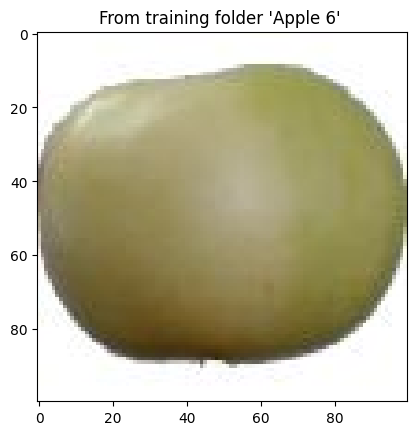

In [ ]:
image_path = os.path.join(training_path, 'Apple 6', 'r0_0_100.jpg')

print("checking if path is working and data extraction worked")
if os.path.exists(image_path):
    print("Image file exists.")
else:
    print("Image file does not exist.")
    raise FileNotFoundError(f"Image file not found: {image_path}")


image = Image.open(image_path)
plt.imshow(image)
plt.axis("on")
plt.title("From training folder 'Apple 6' " )
plt.show()

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100,100,3)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(141, activation='softmax'))
#model.compile(loss = 'categorical_crossentropy',
 #             optimizer = SGD(0.001),
  #            metrics = ['accuracy'])

print(model.summary())
# might be too much # model.add(Dropout(0.5))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 96, 96, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 147456)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      18,874,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 141)                 │          18,189 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,912,077 (72.14 MB)

 Trainable params: 18,912,077 (72.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(loss = 'categorical_crossentropy',optimizer = "SGD", metrics = ['accuracy'])

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    training_path,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    testing_path,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)

Found 70491 images belonging to 141 classes.
Found 23619 images belonging to 141 classes.


In [ ]:
batch_size = 32
epochs = 10

history = model.fit(
   train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=test_generator
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2203/2203 ━━━━━━━━━━━━━━━━━━━━ 260s 115ms/step - accuracy: 0.1100 - loss: 3.9778 - val_accuracy: 0.6510 - val_loss: 1.1584
Epoch 2/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 259s 116ms/step - accuracy: 0.6678 - loss: 1.0624 - val_accuracy: 0.8530 - val_loss: 0.5246
Epoch 3/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 256s 113ms/step - accuracy: 0.8462 - loss: 0.4843 - val_accuracy: 0.8919 - val_loss: 0.3354
Epoch 4/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 261s 113ms/step - accuracy: 0.8946 - loss: 0.3264 - val_accuracy: 0.9243 - val_loss: 0.2676
Epoch 5/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 257s 116ms/step - accuracy: 0.9305 - loss: 0.2129 - val_accuracy: 0.9546 - val_loss: 0.1651
Epoch 6/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 249s 113ms/step - accuracy: 0.9425 - loss: 0.1756 - val_accuracy: 0.9410 - val_loss: 0.1841
Epoch 7/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 256s 116ms/step - accuracy: 0.9577 - loss: 0.1293 - val_accuracy: 0.9531 - val_loss: 0.1697
Epoch 8/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 256s 116ms/step - accuracy: 0.9

In [ ]:
model.save('/content/drive/MyDrive/fruit_saved.h5')

In [ ]:
history_dict = history.history
history_dict

{'accuracy': [0.2634662687778473,
  0.7304336428642273,
  0.8517399430274963,
  0.9045693874359131,
  0.935225784778595,
  0.9459647536277771,
  0.9593423008918762,
  0.9268559217453003,
  0.9566752910614014,
  0.9680668711662292],
 'loss': [2.9175283908843994,
  0.845081627368927,
  0.4742788076400757,
  0.2943103015422821,
  0.19963718950748444,
  0.16803297400474548,
  0.12662915885448456,
  0.319337397813797,
  0.1346694380044937,
  0.10117804259061813],
 'val_accuracy': [0.6510436534881592,
  0.8529996871948242,
  0.8918667435646057,
  0.924340546131134,
  0.9546127915382385,
  0.9409797191619873,
  0.953088641166687,
  0.9510986804962158,
  0.969685435295105,
  0.9699394702911377],
 'val_loss': [1.1583565473556519,
  0.5246399641036987,
  0.3354339301586151,
  0.26763489842414856,
  0.16513203084468842,
  0.18413721024990082,
  0.16971097886562347,
  0.14995741844177246,
  0.1078585684299469,
  0.10831595957279205]}

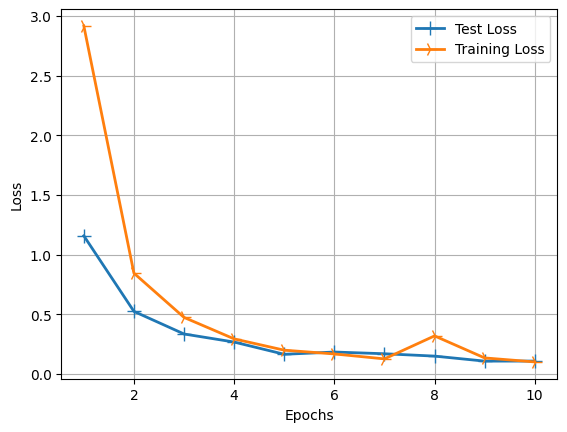

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
line1 = plt.plot(epochs, val_loss_values, label='Test Loss')
line2 = plt.plot(epochs, loss_values, label='Training Loss')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


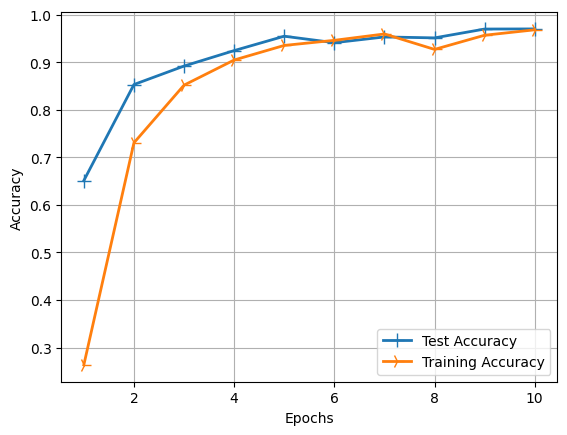

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_acc_values, label='Test Accuracy')
line2 = plt.plot(epochs, acc_values, label='Training Accuracy')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/fruit_saved.h5')

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/fruit_saved.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Actual Label: Apple 6, Predicted Label: Apple 6


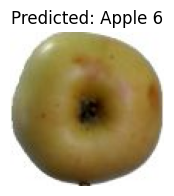

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Actual Label: Cauliflower 1, Predicted Label: Cauliflower 1


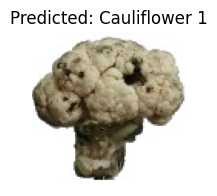

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Actual Label: Banana Lady Finger 1, Predicted Label: Banana Lady Finger 1


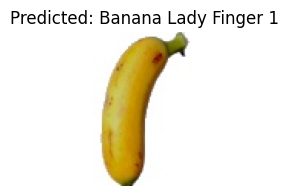

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image
import os

def imgshow(title="", image=None, size=6):
    w, h = image.size
    aspect_ratio = w / h
    plt.figure(figsize=(size * aspect_ratio, size))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


sample_image_paths = [
    '/content/fruitsReady/fruits-360_dataset_100x100/fruits-360/Training/Apple 6/r0_0_100.jpg',
    '/content/fruitsReady/fruits-360_dataset_100x100/fruits-360/Training/Cauliflower 1/111_100.jpg',
    '/content/fruitsReady/fruits-360_dataset_100x100/fruits-360/Training/Banana Lady Finger 1/105_100.jpg'
]

for i in range(0, len(sample_image_paths)):
    img_path = sample_image_paths[i]
    sample_image = load_img(img_path, target_size=(100, 100))
    sample_image_array = img_to_array(sample_image) / 255.0
    sample_image_array = np.expand_dims(sample_image_array, axis=0)
    predictions = model.predict(sample_image_array)
    predicted_class_index = np.argmax(predictions, axis=1)
    class_labels = train_generator.class_indices
    class_labels = {v: k for k, v in class_labels.items()}
    predicted_class_label = class_labels[predicted_class_index[0]]
    predicted_class_folder = os.path.join(training_path, predicted_class_label)
    predicted_class_image_files = os.listdir(predicted_class_folder)
    predicted_class_image_path = os.path.join(predicted_class_folder, predicted_class_image_files[0])
    predicted_fruit_image = Image.open(predicted_class_image_path)
    print(f"Actual Label: {img_path.split('/')[-2]}, Predicted Label: {predicted_class_label}")
    imgshow(f"Predicted: {predicted_class_label}", predicted_fruit_image, size=2)
